### Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

____________

# Look over data

In [2]:
root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

files = glob.glob(
    os.path.join(root, "**", "alldata_final.csv"),
    recursive=True
)

print(f"Found {len(files)} alldata_final.csv files")

Found 14 alldata_final.csv files


In [3]:
summary_rows = []

for file_path in files:

    try:

        df = pd.read_csv(file_path)

        participant = file_path.split("/")[-3]
        session = file_path.split("/")[-2]

        row = {
            "participant": participant,
            "session": session,
            "rows": len(df),
            "columns": len(df.columns),

            "missing_total_%":
                round(df.isna().mean().mean() * 100, 2),

            "duplicates":
                int(df.duplicated().sum()),

            "has_ECG":
                "ECG_HR_smooth" in df.columns,

            "has_EEG":
                "frontal alpha" in df.columns,

            "has_eye_tracking":
                "final_label" in df.columns,

            "has_typology":
                "typology" in df.columns,

            "has_landuse":
                "landuse_en" in df.columns,

            "has_corrected_gps":
                (
                    "longitude_corrected" in df.columns
                    and
                    "latitude_corrected" in df.columns
                ),

            "has_original_gps":
                (
                    "original_longitude" in df.columns
                    and
                    "original_latitude" in df.columns
                ),
        }

        summary_rows.append(row)

    except Exception as e:

        print(f"FAILED: {file_path}")
        print(e)

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values("missing_total_%",ascending=False)

,participant,session,rows,columns,missing_total_%,duplicates,has_ECG,has_EEG,has_eye_tracking,has_typology,has_landuse,has_corrected_gps,has_original_gps
3,sub-OE015,ses-Norreport,1442,77,26.08,0,True,True,False,True,True,True,True
8,sub-OE019,ses-Hellerup,821,77,26.07,0,True,True,False,True,True,True,True
13,sub-OE010,ses-Nordhavn,1455,91,25.20,0,True,True,True,True,True,True,True
11,sub-OE023,ses-Nordhavn,1689,77,16.37,0,True,True,False,True,True,True,True
1,sub-OE005,ses-Hellerup,1459,87,10.64,0,True,True,True,True,True,True,True
4,sub-OE002,ses-Hellerup,1426,87,10.27,0,True,True,True,True,True,True,True
7,sub-OE009,ses-Nordhavn,1659,87,9.96,0,True,True,True,True,True,True,True
12,sub-OE004,ses-Norreport,1272,87,9.12,0,True,True,True,True,True,True,True
5,sub-OE022,ses-Norreport,1534,77,7.66,0,True,True,False,True,True,True,True
2,sub-OE018,ses-Hellerup,1591,77,5.90,0,True,True,False,True,True,True,True



Found 14 alldata_final.csv files

Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE020/ses-Nordhavn/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE005/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE018/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE015/ses-Norreport/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE002/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE022/ses-Norreport/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE022/ses-Nordhavn/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE009/ses-Nordhavn/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE019/ses-Hellerup/alldata_final.csv
Reading: /mnt/raid/emotional_data_raquel/fulldata_mine/sub-OE023/ses-Norrebro/alldata_final.csv
Rea

,participant,session,rows,columns,duplicates,missing_total_%,ECG_%,EDA_%,EEG_%,EyeTracking_%,...,Typology_%,Landuse_%,has_ECG,has_EEG,has_eye_tracking,has_typology,has_landuse,has_corrected_gps,has_original_gps,duration_minutes
0,sub-OE020,ses-Nordhavn,1479,77,0,5.00,80.66,99.93,87.63,0.00,...,92.63,100.0,True,True,False,True,True,True,True,25.02
1,sub-OE005,ses-Hellerup,1459,87,0,10.64,79.85,100.00,87.05,98.83,...,99.45,100.0,True,True,True,True,True,True,True,24.97
2,sub-OE018,ses-Hellerup,1591,77,0,5.90,37.15,99.94,88.37,0.00,...,99.62,100.0,True,True,False,True,True,True,True,26.68
3,sub-OE015,ses-Norreport,1442,77,0,26.08,100.00,0.00,0.00,0.00,...,97.78,100.0,True,True,False,True,True,True,True,24.12
4,sub-OE002,ses-Hellerup,1426,87,0,10.27,32.19,99.93,88.15,99.65,...,88.43,100.0,True,True,True,True,True,True,True,24.53
5,sub-OE022,ses-Norreport,1534,77,0,7.66,77.18,99.93,67.67,0.00,...,94.78,100.0,True,True,False,True,True,True,True,25.73
6,sub-OE022,ses-Nordhavn,1432,77,0,5.30,98.95,90.43,88.27,0.00,...,92.32,100.0,True,True,False,True,True,True,True,23.85
7,sub-OE009,ses-Nordhavn,1659,87,0,9.96,72.33,100.00,80.95,99.16,...,94.51,100.0,True,True,True,True,True,True,True,27.82
8,sub-OE019,ses-Hellerup,821,77,0,26.07,98.29,0.00,0.00,0.00,...,99.63,100.0,True,True,False,True,True,True,True,13.82
9,sub-OE023,ses-Norrebro,1513,77,0,5.90,99.34,99.93,78.72,0.00,...,69.33,100.0,True,True,False,True,True,True,True,25.32



GLOBAL DATASET

(20184, 91)

MISSINGNESS



,missing_%
utci,100.000000
utci_stress_category,100.000000
tk_gps_hasfix_value,99.668054
tk_gps_longitude_value,99.246928
tk_gps_latitude_value,99.246928
...,...
longitude_corrected,0.000000
latitude_corrected,0.000000
GazeX,0.000000
GazeY,0.000000


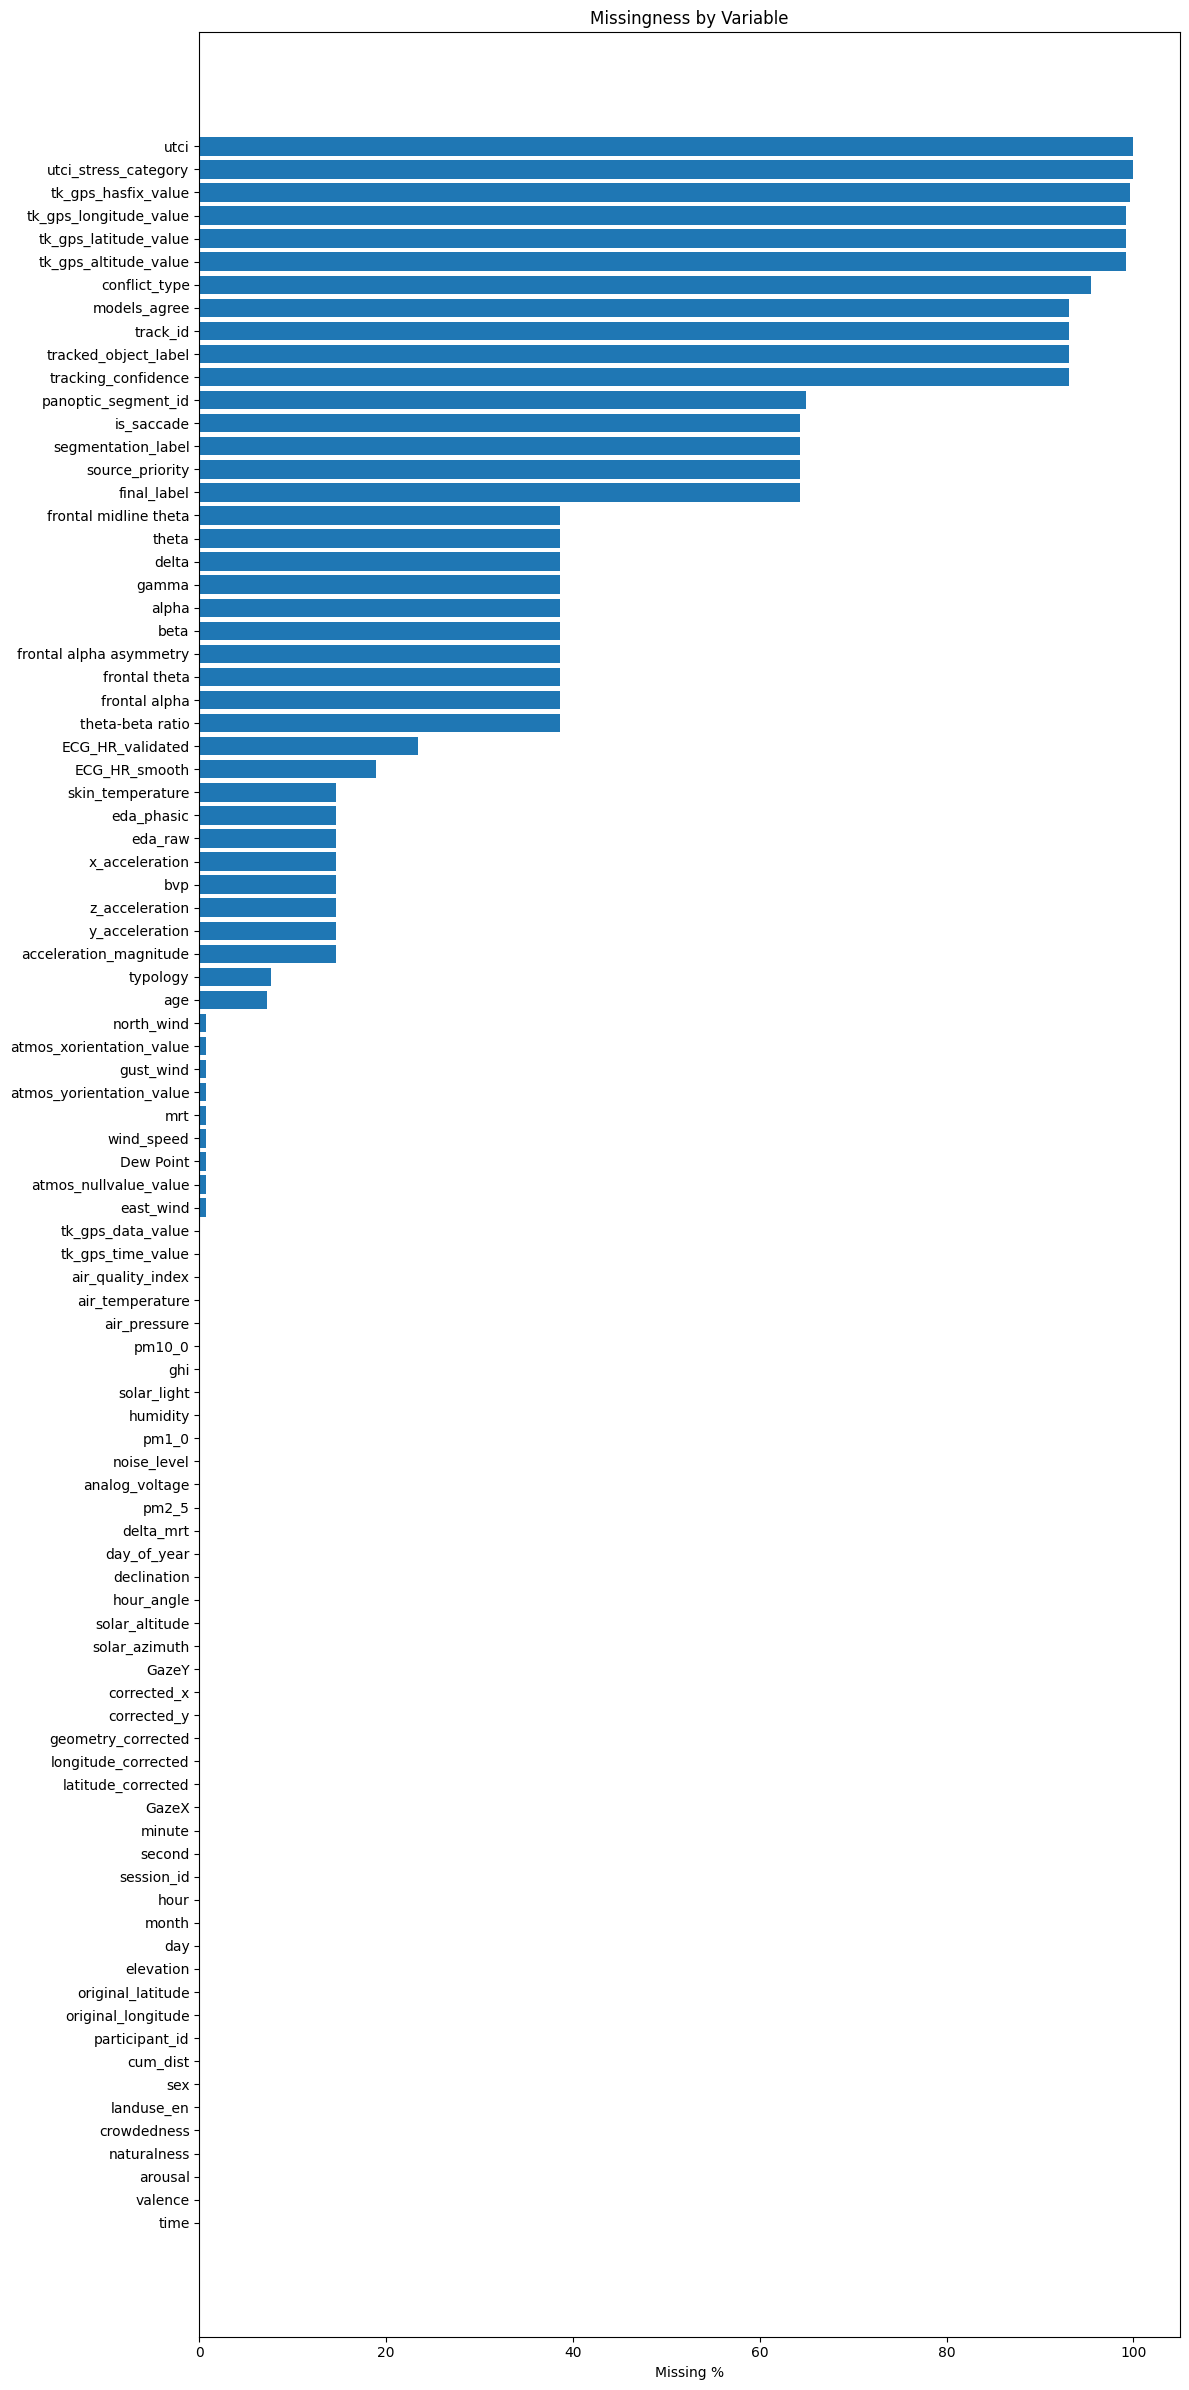


NUMERIC SUMMARY



,count,mean,std,min,25%,50%,75%,max
skin_temperature,17221.0,3.123793e+01,2.433715e+00,2.645000e+01,2.903000e+01,3.182000e+01,3.359000e+01,35.370000
eda_raw,17224.0,7.658913e-01,3.876699e+00,0.000000e+00,5.445632e-03,7.368124e-03,1.249295e-02,37.745173
eda_phasic,17224.0,-2.614739e-04,1.541698e-01,-3.538719e+00,-7.167340e-04,-7.827095e-05,5.363629e-04,2.445695
x_acceleration,17232.0,-1.549258e+01,2.016262e+01,-6.556250e+01,-2.450000e+01,-1.971875e+01,-1.315625e+01,62.875000
y_acceleration,17232.0,-3.083808e+01,4.889805e+01,-7.268750e+01,-6.225000e+01,-5.903125e+01,4.437500e+00,79.062500
...,...,...,...,...,...,...,...,...
panoptic_segment_id,7076.0,7.713115e+00,5.182897e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.100000e+01,39.000000
tk_gps_latitude_value,152.0,-4.574530e+07,2.114814e+07,-5.570828e+07,-5.570765e+07,-5.570685e+07,-5.570666e+07,-644862.000000
tk_gps_longitude_value,152.0,-1.043359e+07,4.590072e+06,-1.259909e+07,-1.259874e+07,-1.259416e+07,-1.259222e+07,-644862.000000
tk_gps_altitude_value,154.0,1.084594e+03,8.602134e+02,-2.323000e+03,7.230000e+02,9.160000e+02,1.624500e+03,7179.000000



LOW VARIANCE VARIABLES



,std
atmos_nullvalue_value,0.000000
month,0.000000
arousal,0.000000
original_longitude,0.015936
longitude_corrected,0.015967
original_latitude,0.017253
latitude_corrected,0.017298
declination,0.053205
eda_phasic,0.154170
gamma,0.158116



CATEGORY BALANCE


----------------------
typology
----------------------



...

session_id
Nordhavn     7714
Norreport    5660
Hellerup     5297
Norrebro     1513
Name: count, dtype: int64


----------------------
participant_id
----------------------



participant_id
OE023    4614
OE022    2966
OE009    1659
OE018    1591
OE020    1479
OE005    1459
OE010    1455
OE015    1442
OE002    1426
OE004    1272
OE019     821
Name: count, dtype: int64


MODALITY COMPLETENESS MATRIX



,participant,session,rows,missing_total_%,ECG_%,EDA_%,EEG_%,EyeTracking_%,GPS_corrected_%,GPS_original_%,Typology_%,Landuse_%
0,sub-OE020,ses-Nordhavn,1479,5.00,80.66,99.93,87.63,0.00,100.0,100.0,92.63,100.0
1,sub-OE005,ses-Hellerup,1459,10.64,79.85,100.00,87.05,98.83,100.0,100.0,99.45,100.0
2,sub-OE018,ses-Hellerup,1591,5.90,37.15,99.94,88.37,0.00,100.0,100.0,99.62,100.0
3,sub-OE015,ses-Norreport,1442,26.08,100.00,0.00,0.00,0.00,100.0,100.0,97.78,100.0
4,sub-OE002,ses-Hellerup,1426,10.27,32.19,99.93,88.15,99.65,100.0,100.0,88.43,100.0
5,sub-OE022,ses-Norreport,1534,7.66,77.18,99.93,67.67,0.00,100.0,100.0,94.78,100.0
6,sub-OE022,ses-Nordhavn,1432,5.30,98.95,90.43,88.27,0.00,100.0,100.0,92.32,100.0
7,sub-OE009,ses-Nordhavn,1659,9.96,72.33,100.00,80.95,99.16,100.0,100.0,94.51,100.0
8,sub-OE019,ses-Hellerup,821,26.07,98.29,0.00,0.00,0.00,100.0,100.0,99.63,100.0
9,sub-OE023,ses-Norrebro,1513,5.90,99.34,99.93,78.72,0.00,100.0,100.0,69.33,100.0


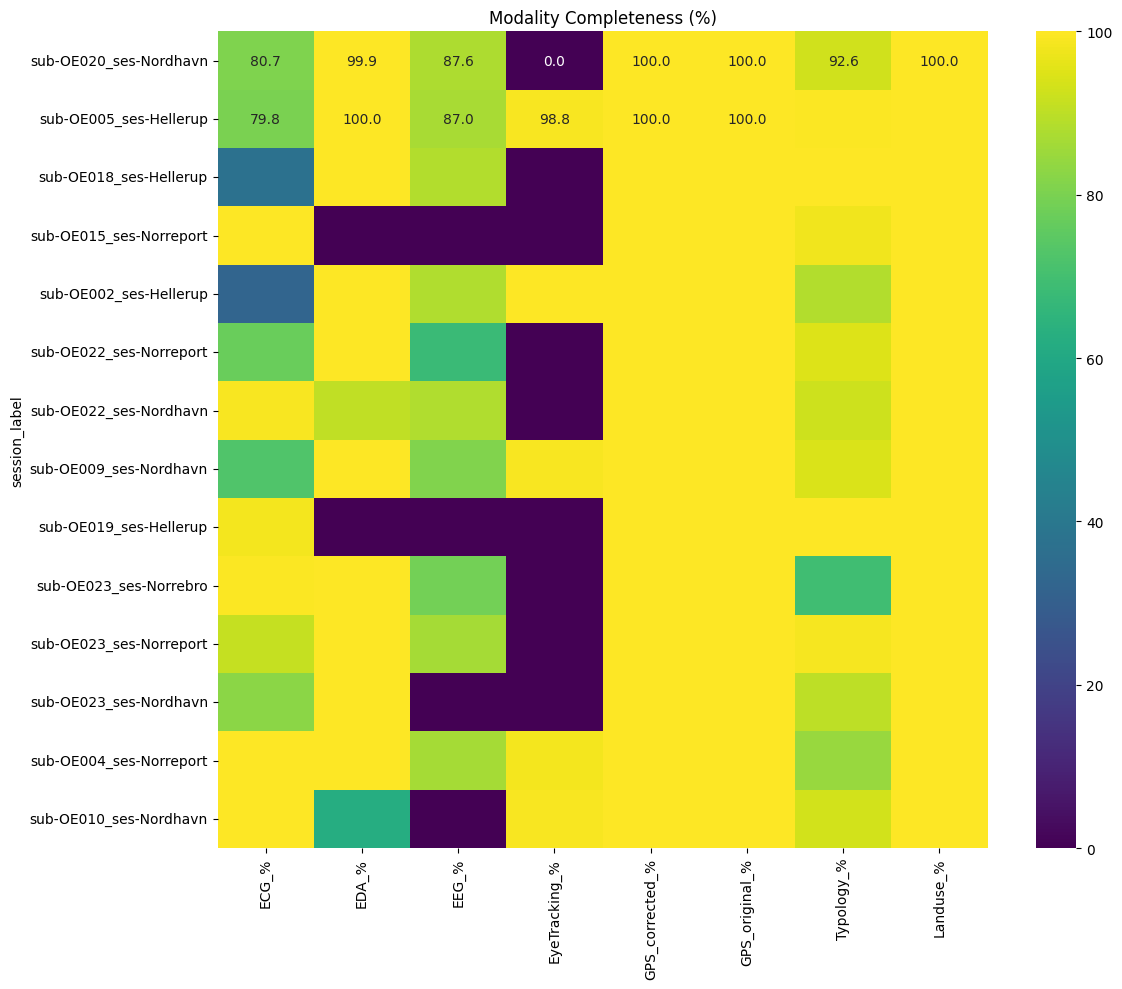


COLUMN CONSISTENCY



,session,n_missing_columns,missing_columns
0,sub-OE020_ses-Nordhavn,14,"tk_gps_altitude_value, final_label, conflict_t..."
1,sub-OE005_ses-Hellerup,4,"tk_gps_longitude_value, tk_gps_altitude_value,..."
2,sub-OE018_ses-Hellerup,14,"tk_gps_altitude_value, final_label, conflict_t..."
3,sub-OE015_ses-Norreport,14,"tk_gps_altitude_value, final_label, conflict_t..."
4,sub-OE002_ses-Hellerup,4,"tk_gps_longitude_value, tk_gps_altitude_value,..."
5,sub-OE022_ses-Norreport,14,"tk_gps_altitude_value, final_label, conflict_t..."
6,sub-OE022_ses-Nordhavn,14,"tk_gps_altitude_value, final_label, conflict_t..."
7,sub-OE009_ses-Nordhavn,4,"tk_gps_longitude_value, tk_gps_altitude_value,..."
8,sub-OE019_ses-Hellerup,14,"tk_gps_altitude_value, final_label, conflict_t..."
9,sub-OE023_ses-Norrebro,14,"tk_gps_altitude_value, final_label, conflict_t..."



DATA AUDIT COMPLETE

Sessions audited: 14
Total rows: 20,184
Total columns: 91


In [4]:
root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

# =========================================================
# FIND ALL alldata_final FILES
# =========================================================

files = glob.glob(
    os.path.join(root, "**", "alldata_final.csv"),
    recursive=True
)

print(f"\nFound {len(files)} alldata_final.csv files\n")

# =========================================================
# SESSION-LEVEL AUDIT
# =========================================================

summary_rows = []

all_dfs = []

for file_path in files:

    print(f"Reading: {file_path}")

    try:

        df = pd.read_csv(file_path)

        # ---------------------------------------------
        # participant/session
        # ---------------------------------------------
        participant = file_path.split("/")[-3]
        session = file_path.split("/")[-2]

        # ---------------------------------------------
        # keep for global dataframe
        # ---------------------------------------------
        all_dfs.append(df)

        # ---------------------------------------------
        # modality completeness
        # ---------------------------------------------
        def completeness(col):

            if col not in df.columns:
                return 0

            return round(
                100 - (df[col].isna().mean() * 100),
                2
            )

        # ---------------------------------------------
        # session summary row
        # ---------------------------------------------
        row = {

            "participant": participant,
            "session": session,

            "rows": len(df),
            "columns": len(df.columns),

            "duplicates":
                int(df.duplicated().sum()),

            "missing_total_%":
                round(
                    df.isna().mean().mean() * 100,
                    2
                ),

            # -----------------------------------------
            # modalities
            # -----------------------------------------
            "ECG_%":
                completeness("ECG_HR_smooth"),

            "EDA_%":
                completeness("eda_phasic"),

            "EEG_%":
                completeness("alpha"),

            "EyeTracking_%":
                completeness("final_label"),

            "GPS_corrected_%":
                completeness("longitude_corrected"),

            "GPS_original_%":
                completeness("original_longitude"),

            "Typology_%":
                completeness("typology"),

            "Landuse_%":
                completeness("landuse_en"),

            # -----------------------------------------
            # column existence
            # -----------------------------------------
            "has_ECG":
                "ECG_HR_smooth" in df.columns,

            "has_EEG":
                "alpha" in df.columns,

            "has_eye_tracking":
                "final_label" in df.columns,

            "has_typology":
                "typology" in df.columns,

            "has_landuse":
                "landuse_en" in df.columns,

            "has_corrected_gps":
                (
                    "longitude_corrected" in df.columns
                    and
                    "latitude_corrected" in df.columns
                ),

            "has_original_gps":
                (
                    "original_longitude" in df.columns
                    and
                    "original_latitude" in df.columns
                ),
        }

        # ---------------------------------------------
        # session duration
        # ---------------------------------------------
        if "time" in df.columns:

            try:

                df["time"] = pd.to_datetime(df["time"])

                duration = (
                    df["time"].max()
                    -
                    df["time"].min()
                )

                row["duration_minutes"] = round(
                    duration.total_seconds() / 60,
                    2
                )

            except:

                row["duration_minutes"] = np.nan

        else:

            row["duration_minutes"] = np.nan

        summary_rows.append(row)

    except Exception as e:

        print(f"\nFAILED: {file_path}")
        print(e)

# =========================================================
# CREATE SUMMARY DATAFRAME
# =========================================================

summary_df = pd.DataFrame(summary_rows)

print("\n==============================")
print("SESSION SUMMARY")
print("==============================\n")

display(summary_df)

# =========================================================
# SAVE SESSION SUMMARY
# =========================================================

# summary_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "session_data_audit_summary.csv"
# )

# summary_df.to_csv(summary_output, index=False)

# print(f"\nSaved session summary:")
# print(summary_output)

# =========================================================
# CONCATENATE ALL DATA
# =========================================================

df_all = pd.concat(
    all_dfs,
    ignore_index=True
)

print("\n==============================")
print("GLOBAL DATASET")
print("==============================\n")

print(df_all.shape)

# =========================================================
# GLOBAL MISSINGNESS
# =========================================================

missing = (
    df_all
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_df = pd.DataFrame({
    "missing_%": missing
})

print("\n==============================")
print("MISSINGNESS")
print("==============================\n")

display(missing_df)

# =========================================================
# SAVE MISSINGNESS
# =========================================================

# missing_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "global_missingness_summary.csv"
# )

# missing_df.to_csv(missing_output)

# =========================================================
# MISSINGNESS PLOT
# =========================================================

missing_df_sorted = missing_df.sort_values(
    "missing_%"
)

plt.figure(figsize=(12, 24))

plt.barh(
    missing_df_sorted.index,
    missing_df_sorted["missing_%"]
)

plt.xlabel("Missing %")
plt.title("Missingness by Variable")

plt.tight_layout()

plt.show()

# =========================================================
# NUMERIC SUMMARY
# =========================================================

numeric_df = df_all.select_dtypes(include=np.number)

summary_stats = numeric_df.describe().T

print("\n==============================")
print("NUMERIC SUMMARY")
print("==============================\n")

display(summary_stats)

# =========================================================
# SAVE NUMERIC SUMMARY
# =========================================================

# numeric_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "numeric_summary_statistics.csv"
# )

# summary_stats.to_csv(numeric_output)

# =========================================================
# LOW VARIANCE VARIABLES
# =========================================================

stds = numeric_df.std().sort_values()

low_variance_df = pd.DataFrame({
    "std": stds
})

print("\n==============================")
print("LOW VARIANCE VARIABLES")
print("==============================\n")

display(low_variance_df.head(30))

# =========================================================
# CATEGORY BALANCE
# =========================================================

categorical_vars = [
    "typology",
    "landuse_en",
    "final_label",
    "session_id",
    "participant_id"
]

print("\n==============================")
print("CATEGORY BALANCE")
print("==============================\n")

for var in categorical_vars:

    if var in df_all.columns:

        print(f"\n----------------------")
        print(var)
        print("----------------------\n")

        display(
            df_all[var]
            .value_counts(dropna=False)
            .head(50)
        )

# =========================================================
# SESSION-LEVEL MODALITY MATRIX
# =========================================================

print("\n==============================")
print("MODALITY COMPLETENESS MATRIX")
print("==============================\n")

modality_df = summary_df[
    [
        "participant",
        "session",
        "rows",
        "missing_total_%",
        "ECG_%",
        "EDA_%",
        "EEG_%",
        "EyeTracking_%",
        "GPS_corrected_%",
        "GPS_original_%",
        "Typology_%",
        "Landuse_%"
    ]
].copy()

display(modality_df)

# =========================================================
# SAVE MODALITY MATRIX
# =========================================================

# modality_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "modality_completeness_matrix.csv"
# )

# modality_df.to_csv(modality_output, index=False)

# =========================================================
# MODALITY HEATMAP
# =========================================================

heatmap_df = modality_df.copy()

heatmap_df["session_label"] = (
    heatmap_df["participant"]
    +
    "_"
    +
    heatmap_df["session"]
)

heatmap_df = heatmap_df.set_index(
    "session_label"
)

heatmap_data = heatmap_df[
    [
        "ECG_%",
        "EDA_%",
        "EEG_%",
        "EyeTracking_%",
        "GPS_corrected_%",
        "GPS_original_%",
        "Typology_%",
        "Landuse_%"
    ]
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis",
    fmt=".1f"
)

plt.title("Modality Completeness (%)")

plt.tight_layout()

plt.show()

# =========================================================
# COLUMN CONSISTENCY CHECK
# =========================================================

print("\n==============================")
print("COLUMN CONSISTENCY")
print("==============================\n")

column_sets = {}

for file_path in files:

    df = pd.read_csv(file_path)

    participant = file_path.split("/")[-3]
    session = file_path.split("/")[-2]

    key = f"{participant}_{session}"

    column_sets[key] = set(df.columns)

all_columns = set.union(*column_sets.values())

column_summary = []

for key, cols in column_sets.items():

    missing_cols = list(all_columns - cols)

    column_summary.append({

        "session": key,
        "n_missing_columns": len(missing_cols),
        "missing_columns": ", ".join(missing_cols)
    })

column_summary_df = pd.DataFrame(column_summary)

display(column_summary_df)

# =========================================================
# SAVE COLUMN CONSISTENCY
# =========================================================

# column_output = (
#     "/mnt/raid/emotional_data_raquel/"
#     "column_consistency_summary.csv"
# )

# column_summary_df.to_csv(column_output, index=False)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n===================================")
print("DATA AUDIT COMPLETE")
print("===================================\n")

print(f"Sessions audited: {len(summary_df)}")
print(f"Total rows: {len(df_all):,}")
print(f"Total columns: {len(df_all.columns)}")

# print("\nSaved outputs:")

# print(summary_output)
# print(missing_output)
# print(numeric_output)
# print(modality_output)
# print(column_output)

In [5]:
for col in [
    "valence",
    "arousal",
    "naturalness",
    "crowdedness"
]:
    print("\n", col)
    print(df_all[col].value_counts(dropna=False))


 valence
valence
0    18742
1     1442
Name: count, dtype: int64

 arousal
arousal
0    20184
Name: count, dtype: int64

 naturalness
naturalness
 5                      7783
 6                      4159
 4                      3726
-9223372036854775808    2925
 7                      1591
Name: count, dtype: int64

 crowdedness
crowdedness
 7                      4702
 4                      3752
 3                      3050
-9223372036854775808    2925
 5                      2897
 8                      1432
 2                      1426
Name: count, dtype: int64


__________

# Exploratory Analysis

Loading → sub-OE002 | ses-Hellerup
Loading → sub-OE004 | ses-Norreport
Loading → sub-OE005 | ses-Hellerup
Loading → sub-OE009 | ses-Nordhavn
Loading → sub-OE010 | ses-Nordhavn
Loading → sub-OE015 | ses-Norreport
Loading → sub-OE018 | ses-Hellerup
Loading → sub-OE019 | ses-Hellerup
Loading → sub-OE020 | ses-Nordhavn
Loading → sub-OE022 | ses-Nordhavn
Loading → sub-OE022 | ses-Norreport
Loading → sub-OE023 | ses-Nordhavn
Loading → sub-OE023 | ses-Norrebro
Loading → sub-OE023 | ses-Norreport


GLOBAL DATASET
(20184, 93)


PARTICIPANTS
participant
sub-OE023    4614
sub-OE022    2966
sub-OE009    1659
sub-OE018    1591
sub-OE020    1479
sub-OE005    1459
sub-OE010    1455
sub-OE015    1442
sub-OE002    1426
sub-OE004    1272
sub-OE019     821
Name: count, dtype: int64


SESSIONS
session
ses-Nordhavn     7714
ses-Norreport    5660
ses-Hellerup     5297
ses-Norrebro     1513
Name: count, dtype: int64


NUMERIC VARIABLES
['skin_temperature', 'eda_raw', 'eda_phasic', 'x_acceleration', 'y_accele

,count,mean,std,min,25%,50%,75%,max
skin_temperature,17221.0,3.123793e+01,2.433715e+00,2.645000e+01,2.903000e+01,3.182000e+01,3.359000e+01,35.370000
eda_raw,17224.0,7.658913e-01,3.876699e+00,0.000000e+00,5.445632e-03,7.368124e-03,1.249295e-02,37.745173
eda_phasic,17224.0,-2.614739e-04,1.541698e-01,-3.538719e+00,-7.167340e-04,-7.827095e-05,5.363629e-04,2.445695
x_acceleration,17232.0,-1.549258e+01,2.016262e+01,-6.556250e+01,-2.450000e+01,-1.971875e+01,-1.315625e+01,62.875000
y_acceleration,17232.0,-3.083808e+01,4.889805e+01,-7.268750e+01,-6.225000e+01,-5.903125e+01,4.437500e+00,79.062500
...,...,...,...,...,...,...,...,...
panoptic_segment_id,7076.0,7.713115e+00,5.182897e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.100000e+01,39.000000
tk_gps_latitude_value,152.0,-4.574530e+07,2.114814e+07,-5.570828e+07,-5.570765e+07,-5.570685e+07,-5.570666e+07,-644862.000000
tk_gps_longitude_value,152.0,-1.043359e+07,4.590072e+06,-1.259909e+07,-1.259874e+07,-1.259416e+07,-1.259222e+07,-644862.000000
tk_gps_altitude_value,154.0,1.084594e+03,8.602134e+02,-2.323000e+03,7.230000e+02,9.160000e+02,1.624500e+03,7179.000000




MISSINGNESS


,missing_%
utci_stress_category,100.000000
utci,100.000000
tk_gps_hasfix_value,99.668054
tk_gps_longitude_value,99.246928
tk_gps_latitude_value,99.246928
...,...
longitude_corrected,0.000000
latitude_corrected,0.000000
GazeX,0.000000
GazeY,0.000000


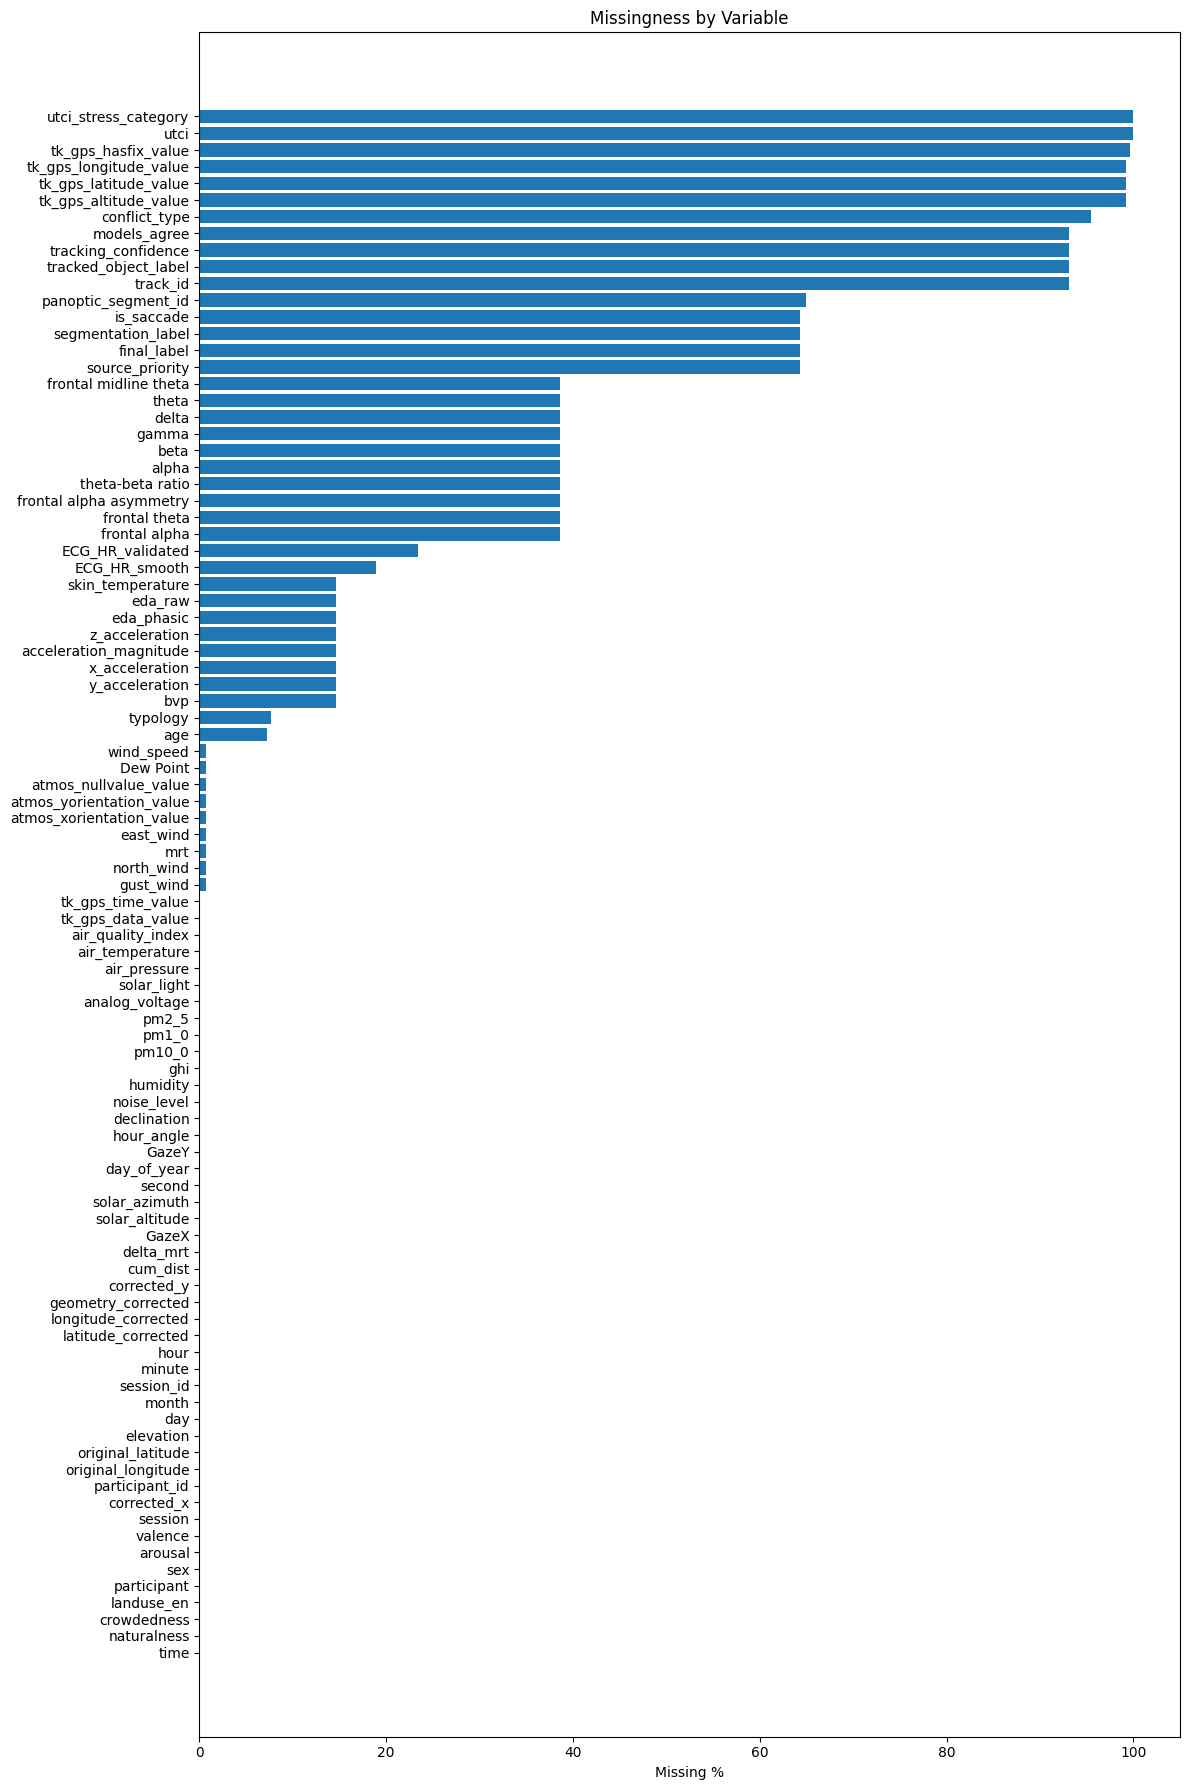



PARTICIPANT_ID COUNTS
participant_id
OE023    4614
OE022    2966
OE009    1659
OE018    1591
OE020    1479
OE005    1459
OE010    1455
OE015    1442
OE002    1426
OE004    1272
OE019     821
Name: count, dtype: int64


SESSION_ID COUNTS
session_id
Nordhavn     7714
Norreport    5660
Hellerup     5297
Norrebro     1513
Name: count, dtype: int64


TYPOLOGY COUNTS
typology
U+N      5828
U+M      5280
U        3472
U+N+M    2308
N        1746
NaN      1550
Name: count, dtype: int64


LANDUSE_EN COUNTS
landuse_en
Mixed Residential and Commercial    5799
Technical Infrastructure            5220
Residential Area                    3659
Commercial / Industrial Area        2654
Recreational Area                   2064
Urban Center                         732
Public Service Area                   56
Name: count, dtype: int64


FINAL_LABEL COUNTS
final_label
NaN              12986
building          1719
road              1457
vegetation        1228
laptop             430
person             361


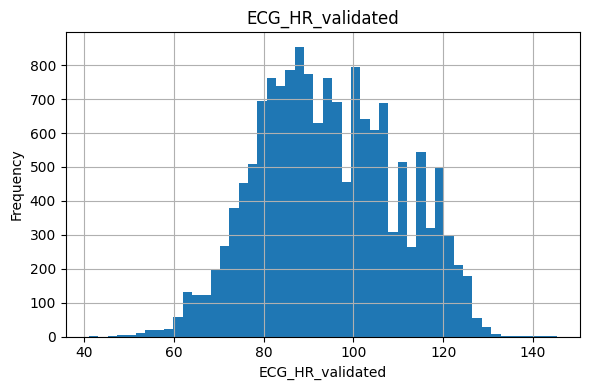

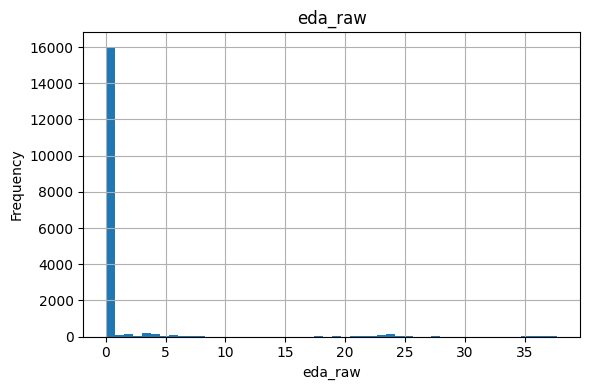

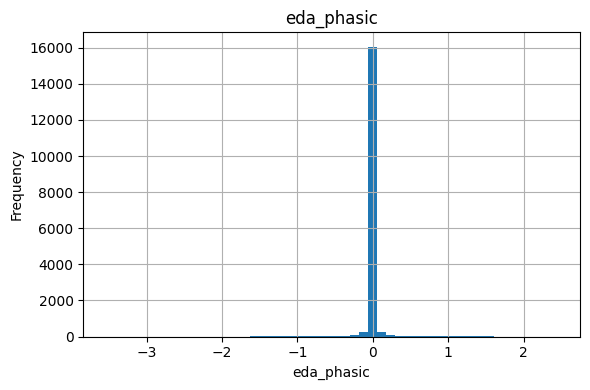

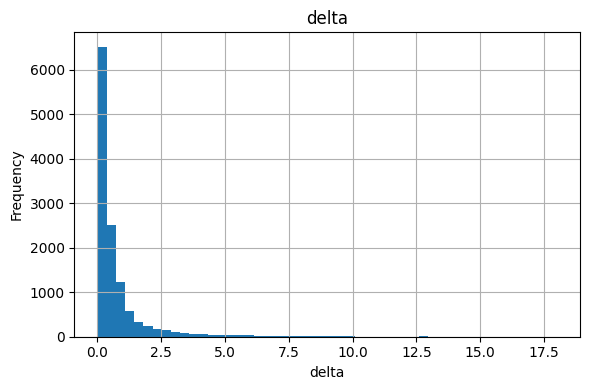

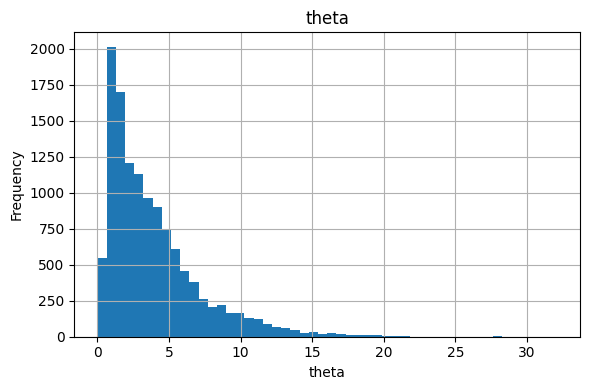

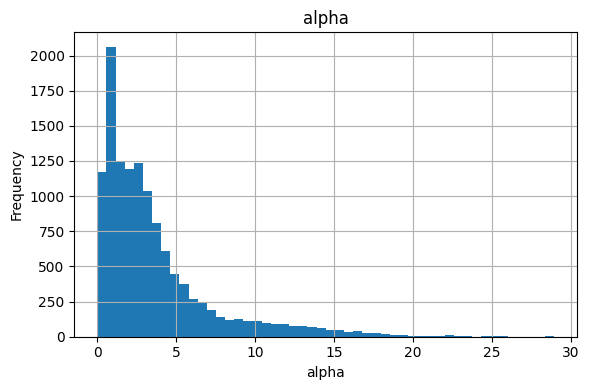

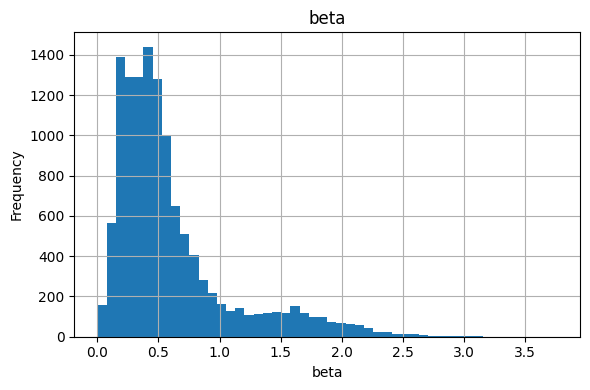

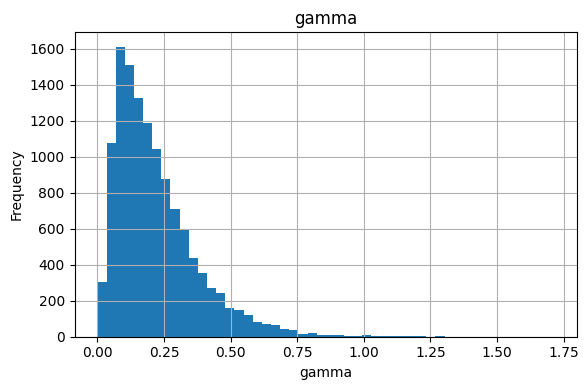

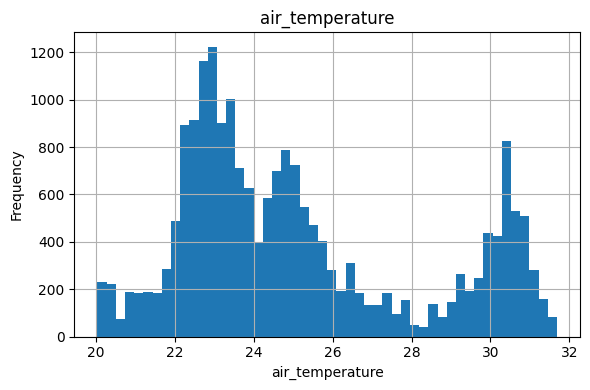

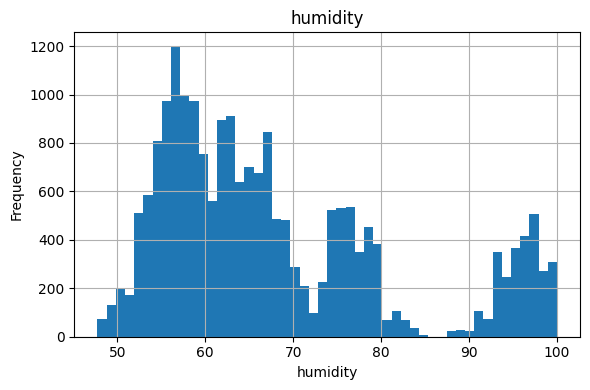

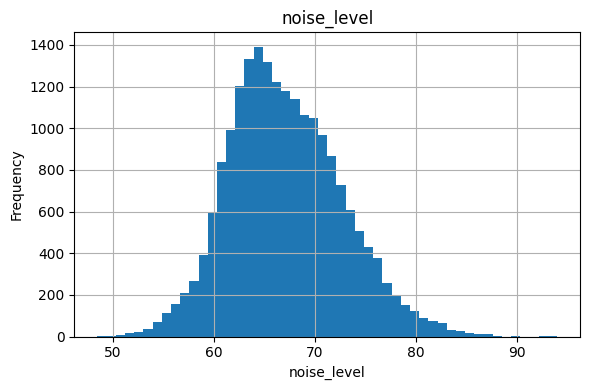

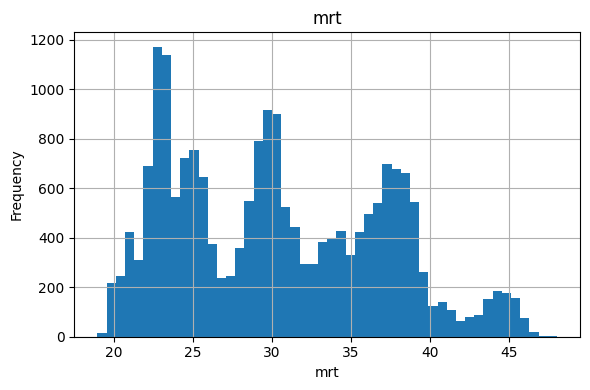

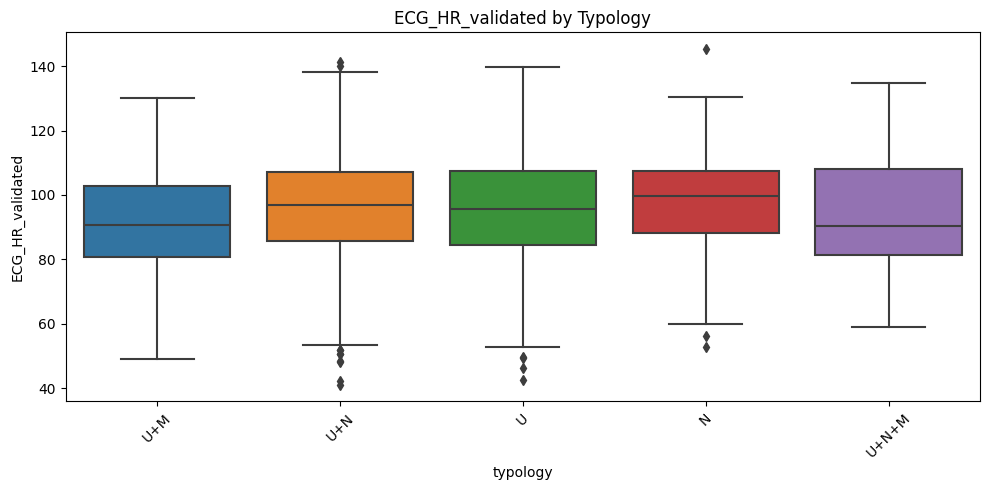

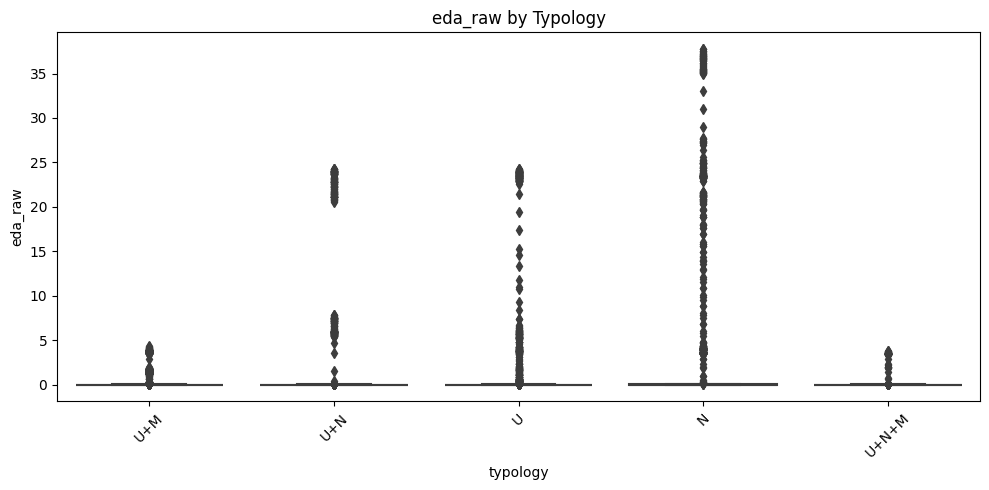

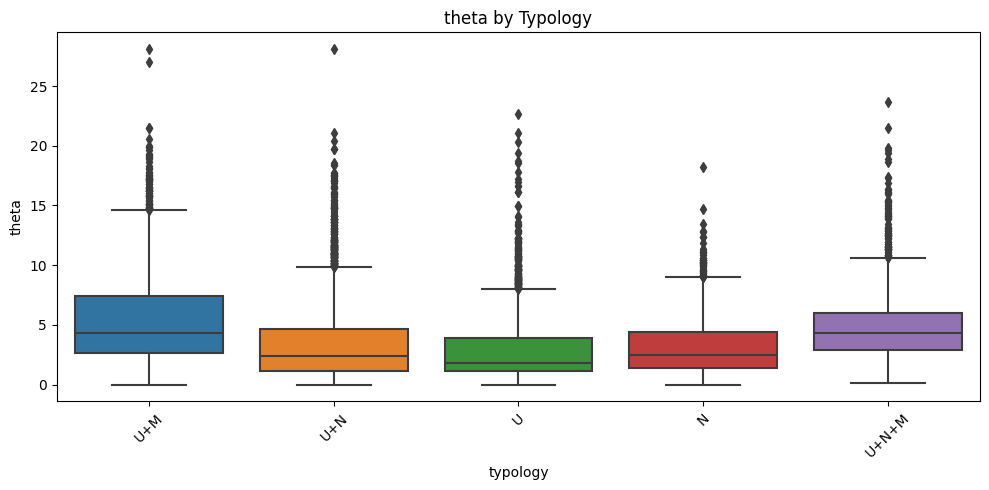

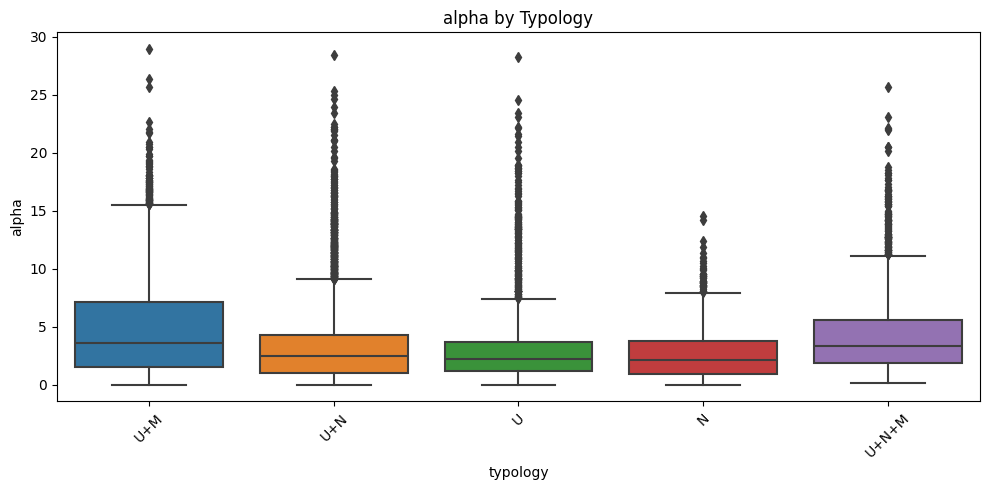

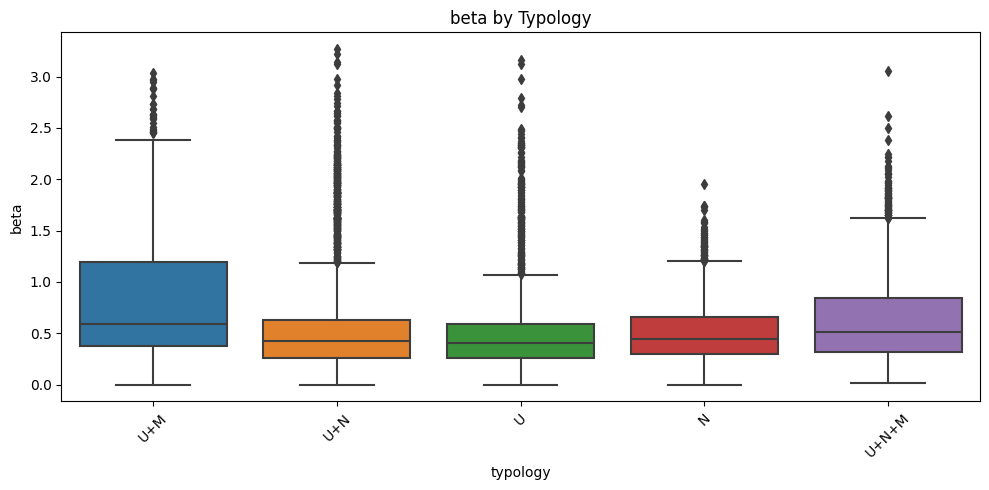

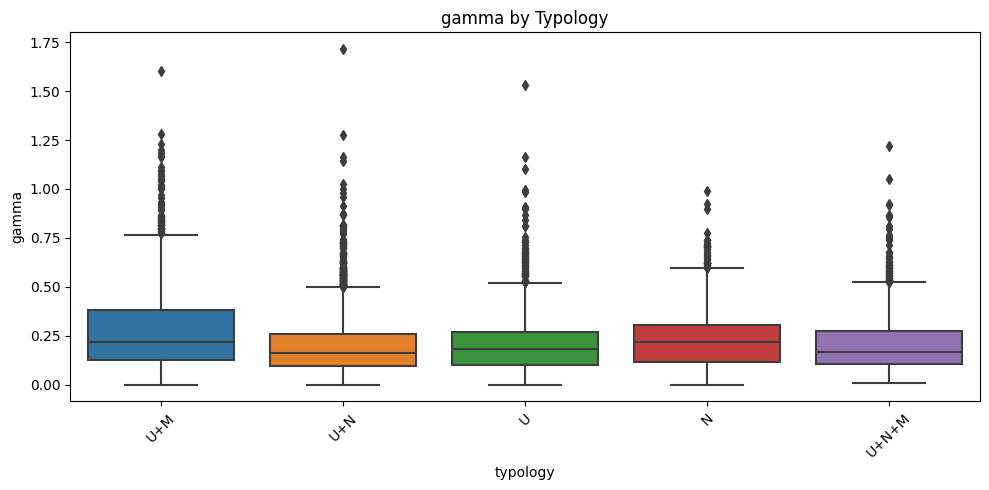

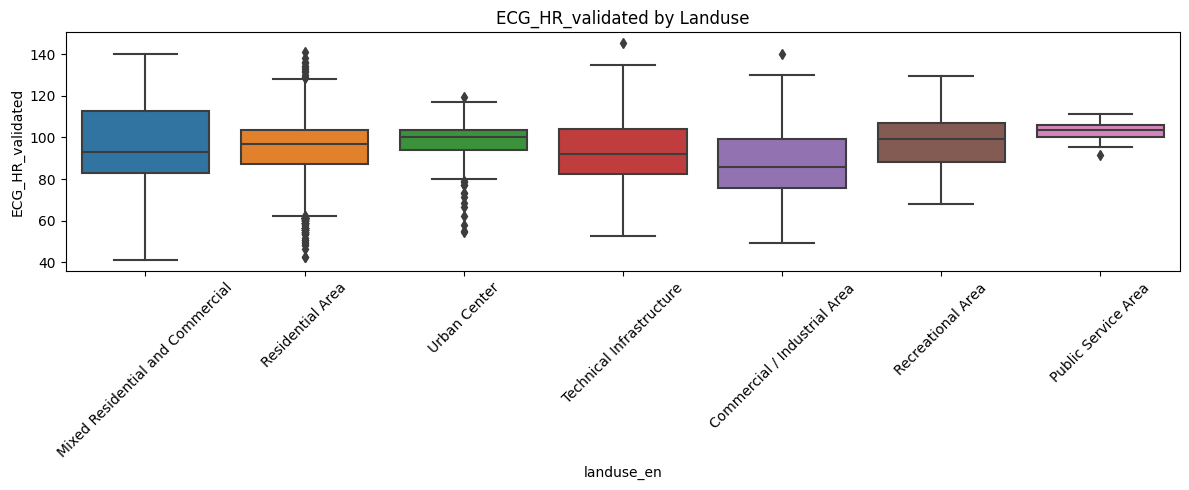

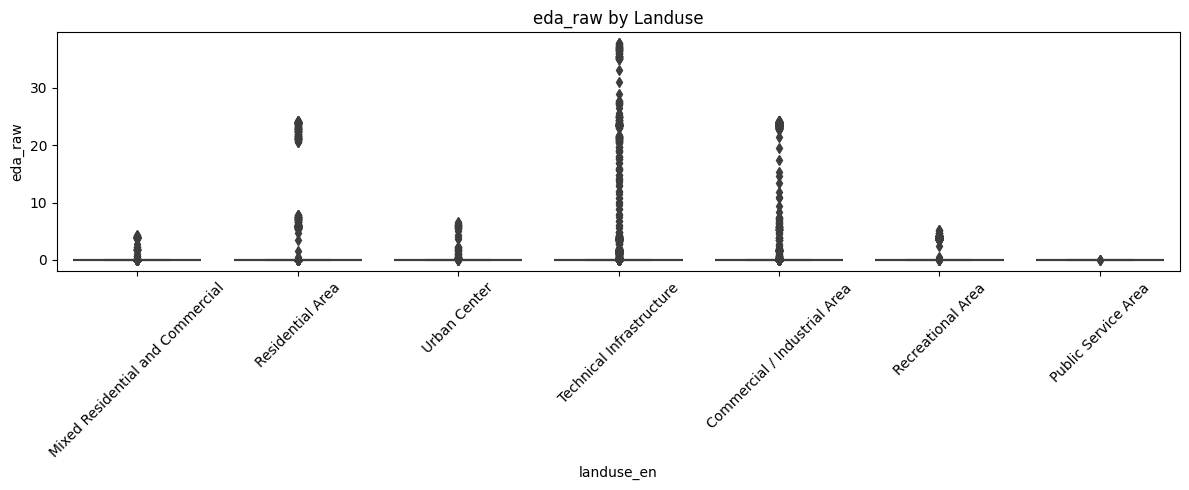

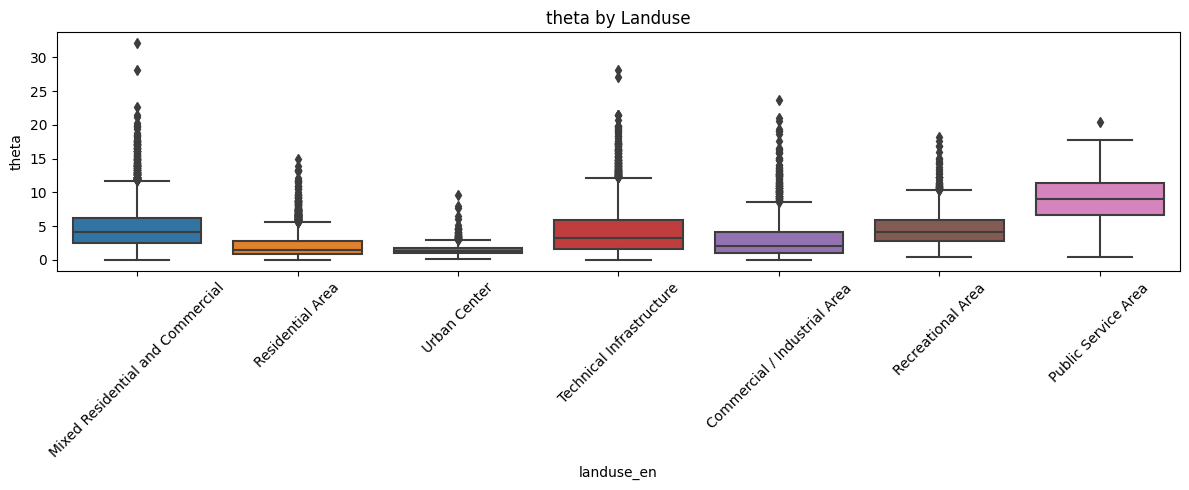

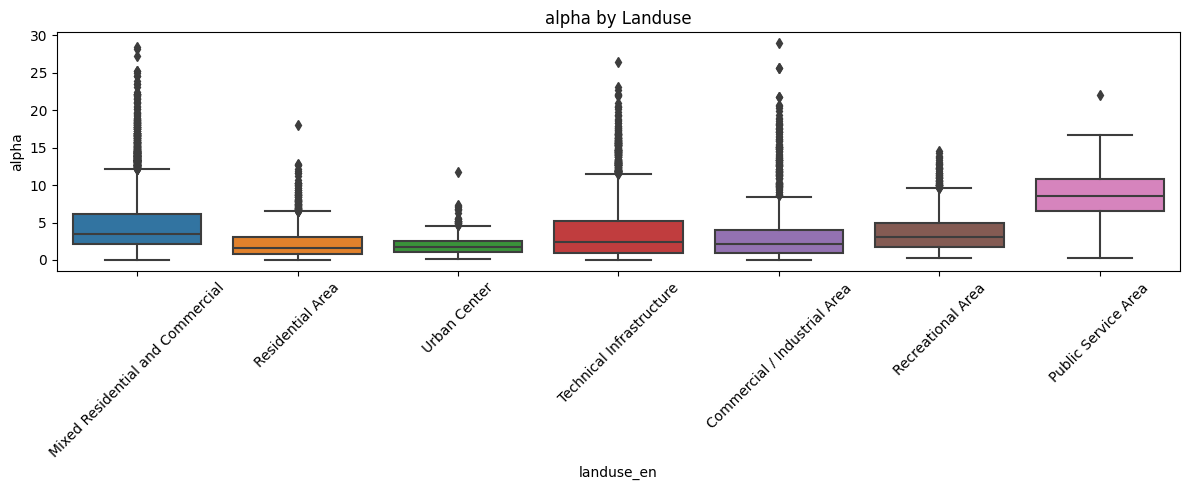

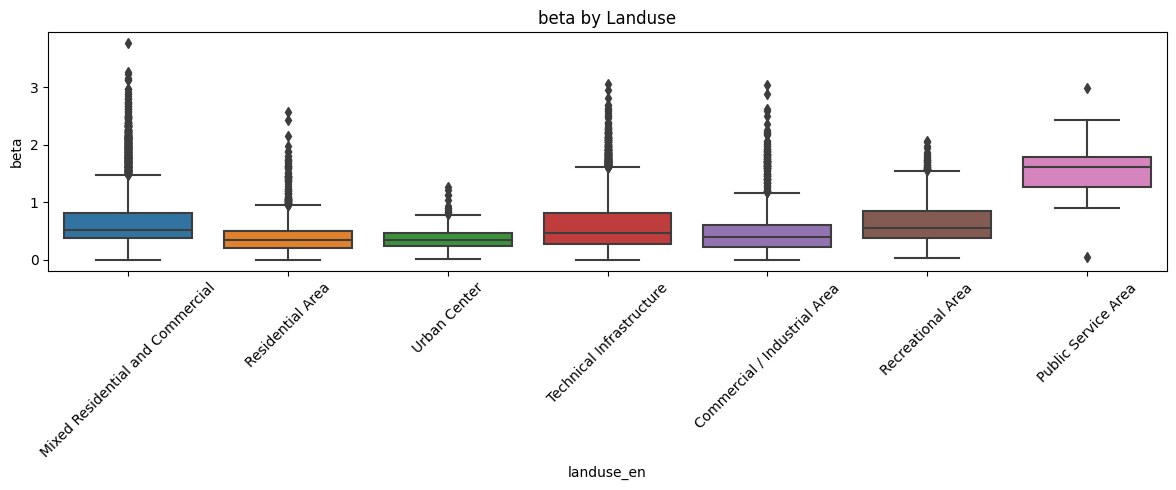

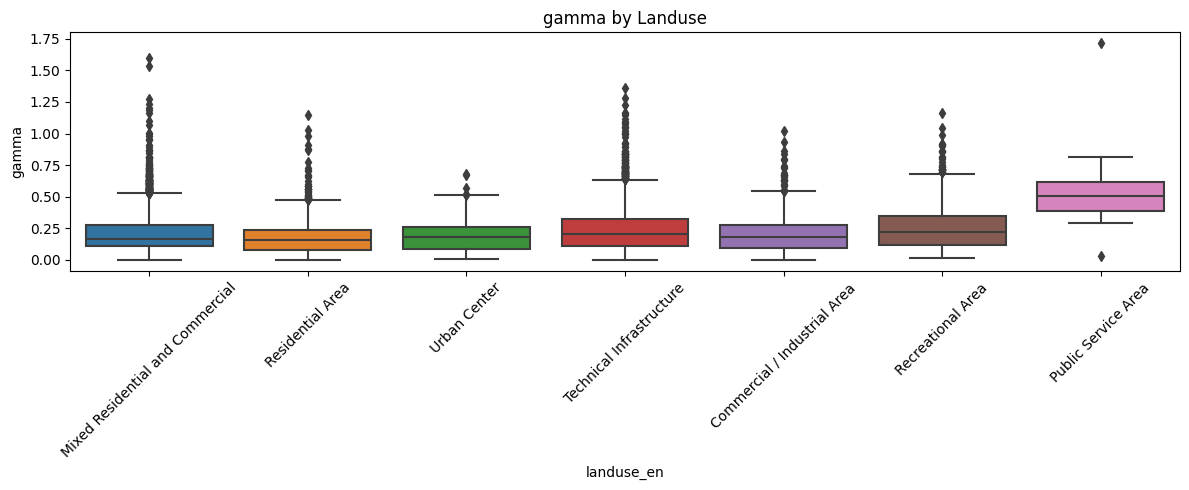



CORRELATION MATRIX


,ECG_HR_validated,eda_raw,eda_phasic,delta,theta,alpha,beta,gamma,air_temperature,humidity,noise_level,mrt
ECG_HR_validated,1.000000,0.052323,0.015838,-0.026997,0.466178,0.540976,0.545965,0.399845,0.220033,-0.171879,0.044809,0.052978
eda_raw,0.052323,1.000000,0.048625,-0.059327,-0.117081,-0.100007,-0.063658,0.067826,0.222247,-0.080653,-0.057875,0.187761
eda_phasic,0.015838,0.048625,1.000000,0.001986,-0.005332,-0.003615,-0.005843,0.000902,-0.000422,0.000465,0.006435,-0.001512
delta,-0.026997,-0.059327,0.001986,1.000000,0.121728,-0.098380,0.008898,0.066989,-0.078370,-0.022230,0.042003,0.023844
theta,0.466178,-0.117081,-0.005332,0.121728,1.000000,0.812600,0.811333,0.561455,-0.148882,-0.167048,0.055166,-0.087133
alpha,0.540976,-0.100007,-0.003615,-0.098380,0.812600,1.000000,0.904112,0.603542,-0.078973,-0.220078,0.050783,-0.077341
beta,0.545965,-0.063658,-0.005843,0.008898,0.811333,0.904112,1.000000,0.751692,-0.076133,-0.249018,0.038573,-0.039564
gamma,0.399845,0.067826,0.000902,0.066989,0.561455,0.603542,0.751692,1.000000,-0.042519,-0.226171,-0.010944,0.041325
air_temperature,0.220033,0.222247,-0.000422,-0.078370,-0.148882,-0.078973,-0.076133,-0.042519,1.000000,-0.696099,-0.082647,0.582302
humidity,-0.171879,-0.080653,0.000465,-0.022230,-0.167048,-0.220078,-0.249018,-0.226171,-0.696099,1.000000,0.118505,-0.525155


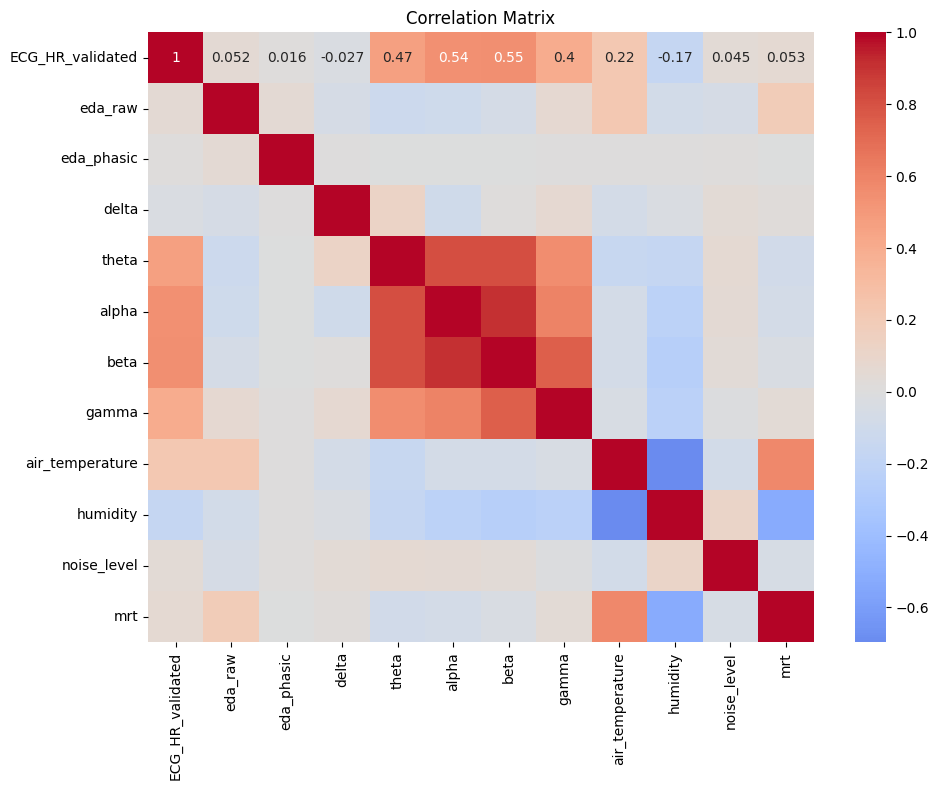



SESSION SUMMARY


,participant_id,session_id,ECG_HR_validated,eda_raw,theta,alpha,beta,gamma,air_temperature,humidity,noise_level,mrt
0,OE002,Hellerup,93.836622,1.436959,1.896352,2.516168,0.451848,0.234833,22.827495,78.071533,64.536450,27.547005
1,OE004,Norreport,78.132034,0.020392,3.498244,2.222575,0.371625,0.127767,22.765441,95.638999,68.665091,25.327548
2,OE005,Hellerup,88.172355,5.942117,1.835934,1.947256,0.425352,0.243304,29.936709,57.166430,66.064944,38.640205
3,OE009,Nordhavn,78.272412,0.006401,2.706902,2.347714,0.375630,0.123436,21.083284,76.359446,68.159545,24.656239
4,OE010,Nordhavn,110.510518,0.022127,NaN,NaN,NaN,NaN,25.060704,66.776997,66.797344,28.220222
5,OE015,Norreport,103.324210,NaN,NaN,NaN,NaN,NaN,22.549365,96.082025,69.249563,24.947664
6,OE018,Hellerup,103.041357,0.495379,0.840961,0.835547,0.193789,0.068836,30.539072,55.919922,66.570684,35.133809
7,OE019,Hellerup,97.338046,NaN,NaN,NaN,NaN,NaN,30.570719,53.836943,66.881817,32.958943
8,OE020,Nordhavn,86.595616,0.007088,4.087264,4.296730,0.571944,0.189199,24.595085,59.335413,66.492010,28.375552
9,OE022,Nordhavn,113.172611,0.015533,9.313722,10.384849,1.442762,0.369860,26.848812,55.599581,67.862155,33.001273




EXPLORATORY ANALYSIS COMPLETE


In [7]:
full_data_root = "/mnt/raid/emotional_data_raquel/fulldata_mine"

# ======================================================
# LOAD ALL alldata_final.csv FILES
# ======================================================

all_dfs = []

for participant in sorted(os.listdir(full_data_root)):

    participant_path = os.path.join(full_data_root, participant)

    if not os.path.isdir(participant_path):
        continue

    for session in sorted(os.listdir(participant_path)):

        session_path = os.path.join(participant_path, session)

        if not os.path.isdir(session_path):
            continue

        file_path = os.path.join(
            session_path,
            "alldata_final.csv"
        )

        if not os.path.exists(file_path):
            continue

        print(f"Loading → {participant} | {session}")

        try:
            df = pd.read_csv(file_path)

            df["participant"] = participant
            df["session"] = session

            all_dfs.append(df)

        except Exception as e:
            print(f"ERROR: {e}")

# ======================================================
# CONCATENATE
# ======================================================

df_all = pd.concat(all_dfs, ignore_index=True)

print("\n")
print("=" * 80)
print("GLOBAL DATASET")
print("=" * 80)

print(df_all.shape)

# ======================================================
# BASIC OVERVIEW
# ======================================================

print("\n")
print("=" * 80)
print("PARTICIPANTS")
print("=" * 80)

print(df_all["participant"].value_counts())

print("\n")
print("=" * 80)
print("SESSIONS")
print("=" * 80)

print(df_all["session"].value_counts())

# ======================================================
# NUMERIC VARIABLES
# ======================================================

numeric_cols = df_all.select_dtypes(
    include=np.number
).columns.tolist()

print("\n")
print("=" * 80)
print("NUMERIC VARIABLES")
print("=" * 80)

print(numeric_cols)

# ======================================================
# DESCRIPTIVE STATISTICS
# ======================================================

desc_stats = (
    df_all[numeric_cols]
    .describe()
    .T
)

print("\n")
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

display(desc_stats)

# ======================================================
# SAVE DESCRIPTIVES
# ======================================================

desc_stats.to_csv(
    "/mnt/raid/emotional_data_raquel/descriptive_statistics.csv"
)

# ======================================================
# MISSINGNESS
# ======================================================

missing_df = pd.DataFrame({

    "missing_%": (
        df_all.isna().mean() * 100
    ).sort_values(ascending=False)

})

print("\n")
print("=" * 80)
print("MISSINGNESS")
print("=" * 80)

display(missing_df)

# ======================================================
# MISSINGNESS PLOT
# ======================================================

plt.figure(figsize=(12, 18))

missing_df_sorted = missing_df.sort_values(
    "missing_%",
    ascending=True
)

plt.barh(
    missing_df_sorted.index,
    missing_df_sorted["missing_%"]
)

plt.xlabel("Missing %")
plt.title("Missingness by Variable")

plt.tight_layout()
plt.show()

# ======================================================
# CATEGORY COUNTS
# ======================================================

categorical_cols = [

    "participant_id",
    "session_id",
    "typology",
    "landuse_en",
    "final_label",
    "sex"

]

for col in categorical_cols:

    if col not in df_all.columns:
        continue

    print("\n")
    print("=" * 80)
    print(f"{col.upper()} COUNTS")
    print("=" * 80)

    print(
        df_all[col]
        .value_counts(dropna=False)
    )

# ======================================================
# HISTOGRAMS
# ======================================================

variables_to_plot = [

    "ECG_HR_validated",
    "eda_raw",
    "eda_phasic",
    "delta",
    "theta",
    "alpha",
    "beta",
    "gamma",
    "air_temperature",
    "humidity",
    "noise_level",
    "mrt"

]

for var in variables_to_plot:

    if var not in df_all.columns:
        continue

    plt.figure(figsize=(6,4))

    df_all[var].hist(
        bins=50
    )

    plt.title(var)

    plt.xlabel(var)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# ======================================================
# BOXPLOTS BY TYPOLOGY
# ======================================================

variables_for_boxplots = [

    "ECG_HR_validated",
    "eda_raw",
    "theta",
    "alpha",
    "beta",
    "gamma"

]

for var in variables_for_boxplots:

    if var not in df_all.columns:
        continue

    if "typology" not in df_all.columns:
        continue

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df_all,
        x="typology",
        y=var
    )

    plt.title(f"{var} by Typology")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ======================================================
# BOXPLOTS BY LANDUSE
# ======================================================

for var in variables_for_boxplots:

    if var not in df_all.columns:
        continue

    if "landuse_en" not in df_all.columns:
        continue

    plt.figure(figsize=(12,5))

    sns.boxplot(
        data=df_all,
        x="landuse_en",
        y=var
    )

    plt.title(f"{var} by Landuse")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ======================================================
# CORRELATION MATRIX
# ======================================================

corr_vars = [

    "ECG_HR_validated",
    "eda_raw",
    "eda_phasic",
    "delta",
    "theta",
    "alpha",
    "beta",
    "gamma",
    "air_temperature",
    "humidity",
    "noise_level",
    "mrt"

]

corr_vars = [
    c for c in corr_vars
    if c in df_all.columns
]

corr_df = df_all[corr_vars].corr()

print("\n")
print("=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)

display(corr_df)

# ======================================================
# CORRELATION HEATMAP
# ======================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# ======================================================
# SAVE CORRELATION MATRIX
# ======================================================

# corr_df.to_csv(
#     "/mnt/raid/emotional_data_raquel/correlation_matrix.csv"
# )

# ======================================================
# SESSION LEVEL SUMMARY
# ======================================================

session_summary = (

    df_all
    .groupby(
        ["participant_id", "session_id"]
    )
    .agg({

        "ECG_HR_validated": "mean",
        "eda_raw": "mean",
        "theta": "mean",
        "alpha": "mean",
        "beta": "mean",
        "gamma": "mean",
        "air_temperature": "mean",
        "humidity": "mean",
        "noise_level": "mean",
        "mrt": "mean"

    })
    .reset_index()

)

print("\n")
print("=" * 80)
print("SESSION SUMMARY")
print("=" * 80)

display(session_summary)

# ======================================================
# SAVE SESSION SUMMARY
# ======================================================

# session_summary.to_csv(
#     "/mnt/raid/emotional_data_raquel/session_summary.csv",
#     index=False
# )

# ======================================================
# DONE
# ======================================================

print("\n")
print("=" * 80)
print("EXPLORATORY ANALYSIS COMPLETE")
print("=" * 80)

<Axes: xlabel='typology', ylabel='ECG_z'>

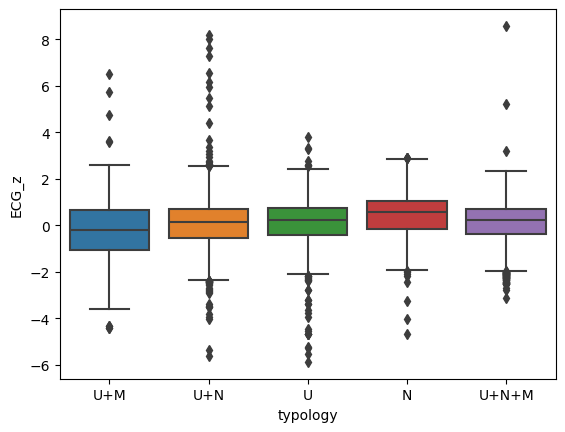

In [9]:
df_all["ECG_z"] = (
    df_all.groupby("participant_id")["ECG_HR_validated"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sns.boxplot(
    data=df_all,
    x="typology",
    y="ECG_z"
)

<Axes: xlabel='typology', ylabel='acceleration_magnitude'>

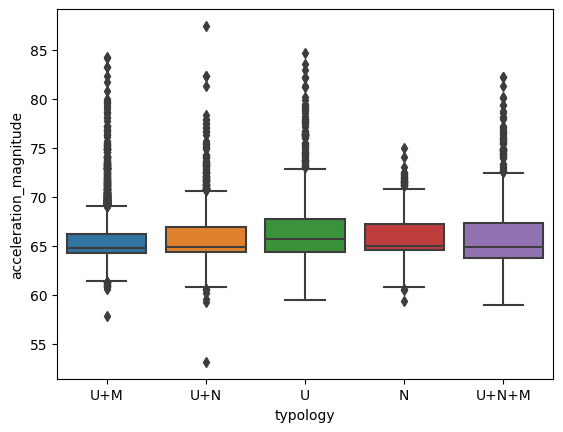

In [10]:
sns.boxplot(
    data=df_all,
    x="typology",
    y="acceleration_magnitude"
)

<Axes: xlabel='typology', ylabel='EDA_z'>

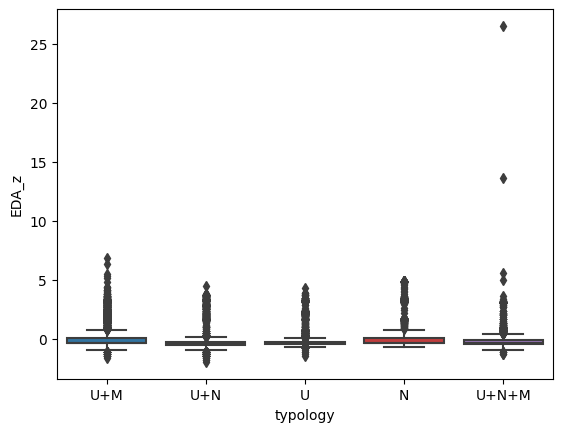

In [11]:
df_all["EDA_log"] = np.log1p(df_all["eda_raw"])

df_all["EDA_z"] = (
    df_all.groupby("participant_id")["EDA_log"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sns.boxplot(
    data=df_all,
    x="typology",
    y="EDA_z"
)

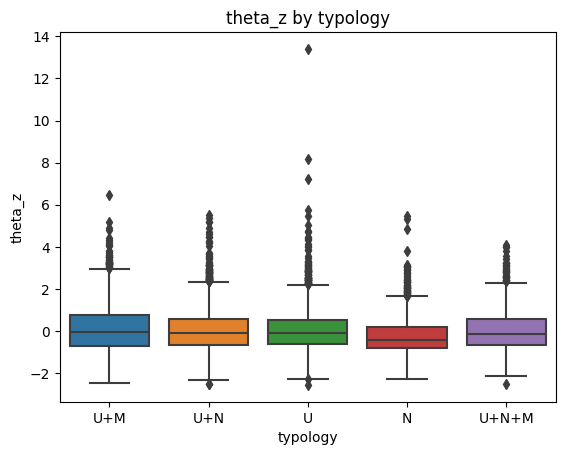

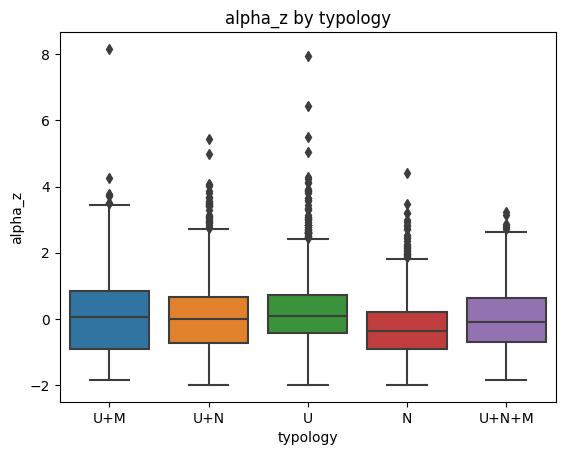

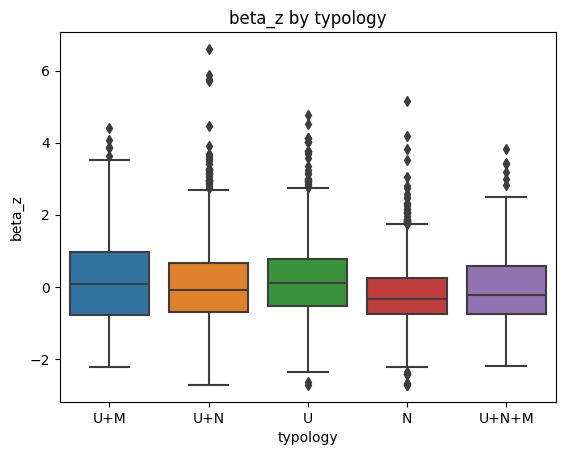

In [12]:
for band in ["theta", "alpha", "beta"]:

    df_all[f"{band}_z"] = (
        df_all.groupby("participant_id")[band]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

    sns.boxplot(
        data=df_all,
        x="typology",
        y=f"{band}_z"
    )

    plt.title(f"{band}_z by typology")
    plt.show()